# 선형회귀

    * 선형회귀
        1. 단순 선형 회귀 : 독립변수가 1개
        2. 다중 선형 회귀 : 독립변수가 2개 이상
        
    * 비용함수 (Cost function)
        1. 손실함수 (Loss function) 또는 목적함수(Objective function)이라고 불린다.
        2. 오차(error)를 계산한다 (실제 값과 예측 값 차이)
        3. 평균 제곱 오차를 최소화 하는 파라미터를 찾는다.
        
    * 경사하강법 (Gradient Descent)
        1. 경사하강법을 활용해 최소 에러 값을 찾는다.
        2. 예를들어 기울기에서 조금씩 내려오면서 0인값을 찾음

In [3]:
# 라이브러리 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split # 검증데이터 분리를 위한 라이브러리
from sklearn.metrics import mean_squared_error       # 회귀모델 평가를 위한 지표 mse를 가져옴

* mean_squared_error 에서 error는 실측값과 예측값 사이의 차이 이것을 오차값이라고 한다.
* 이 오차값에 제곱을한 평균값이라고 보면 됩니다.
* 오차는 작으면 작을수록 좋다.

## 데이터 불러오기

In [5]:
# 데이터 생성
from sklearn.datasets import load_diabetes # 당뇨병 환자 데이터

def make_dataset():
    dataset = load_diabetes()
    df = pd.DataFrame(dataset.data, columns = dataset.feature_names)
    df['target'] = dataset.target

    X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis = 1), 
                                                        df['target'], 
                                                        test_size = 0.2, 
                                                        random_state = 1004)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = make_dataset()
X_train.shape, X_test.shape, y_train.shape, y_test.shape #데이터 크기

((353, 10), (89, 10), (353,), (89,))

In [6]:
# train 샘플
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
152,-0.034575,0.050680,-0.000817,0.070072,0.039710,0.066952,-0.065491,0.108111,0.026717,0.073480
417,-0.052738,-0.044642,0.071397,-0.074527,-0.015328,-0.001314,0.004460,-0.021412,-0.046883,0.003064
172,0.041708,0.050680,0.071397,0.008101,0.038334,0.015909,-0.017629,0.034309,0.073407,0.085907
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
296,0.067136,-0.044642,-0.061174,-0.040099,-0.026336,-0.024487,0.033914,-0.039493,-0.056153,-0.059067


* 수치형으로 만들어진 데이터를 확인할 수 있다.

In [7]:
# 타겟 샘플
y_train.head()

152    292.0
417     55.0
172    295.0
438    104.0
296     89.0
Name: target, dtype: float64

<Axes: >

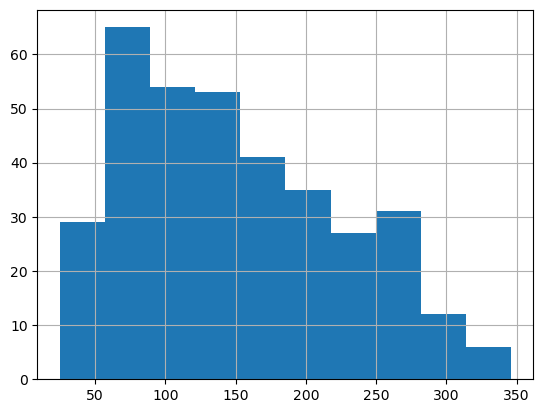

In [8]:
# 타겟 확인
y_train.hist()

## 선형회귀

    * 선형회귀 모델 만들기

In [13]:
# 선형 회귀
from sklearn.linear_model import LinearRegression
model = LinearRegression()         # 모델 변수 만들기
model.fit(X_train, y_train)        # 모델 학습 (X데이터와 target 데이터를 넣어준다.)
pred = model.predict(X_test)       # 모델 예측 (X테스트 데이터로 확인을 한다.) > 예측된 결과값을 pred에 저장
mean_squared_error(y_test, pred)   # 평가 하기 : (실제데이터값 y_test, 예측데이터값 pred를 넣어준다) > 오차범위를 알려줌

2707.631852164159

## 릿지회귀

* 회귀를 위한 선형 모델
  
* 규제 (regularization) 적용
    * 오버피팅 되지 않도록 한다.
    * 규제 방식 : L2 규제
    * 파라미터 (alpha) 값을 활용해 조절한다.
    * alpha값이 커질 수록 회귀 계수 값을 작게 만든다.
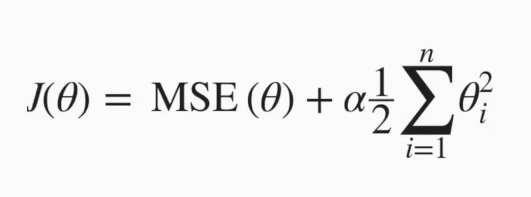 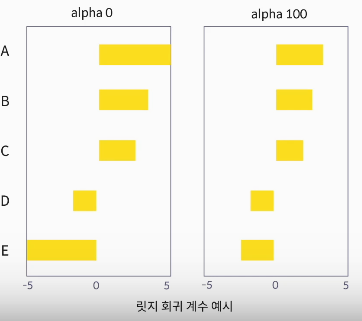

In [14]:
# 릿지 회귀

from sklearn.linear_model import Ridge
model = Ridge()                    # 모델 변수 만들기
model.fit(X_train, y_train)        # 모델 학습 (X데이터와 target 데이터를 넣어준다.)
pred = model.predict(X_test)       # 모델 예측 (X테스트 데이터로 확인을 한다.) > 예측된 결과값을 pred에 저장
mean_squared_error(y_test, pred)   # 평가 하기 : (실제데이터값 y_test, 예측데이터값 pred를 넣어준다) > 오차범위를 알려줌

3522.1191842072667

In [16]:
# 회귀 계수 확인하기
model.coef_

# 결과값은 피처들의 회귀 계수로 데이터 칼럼 순서대로 이해하면된다.

array([  31.2934206 ,  -71.44865465,  267.60596214,  197.36249197,
         14.61325736,  -13.88423665, -124.64983613,  106.21296724,
        221.0684933 ,  101.20254637])

In [21]:
# 회귀 계수 확인하기 ( 위 처럼 회귀 계수를 본다면 이해하기 힘들기 때문에 dataFrame 형식으로 변환해서 볼 수 있다)
coef = pd.DataFrame(data = model.coef_, index = X_train.columns, columns = ['alpha1']) # 변수에 저장해주기
coef
# columns = ['alpha1']에 alpha1로 만든이유는 Ridege()의 alpha의 기본값이 1이기 때문이다.

,alpha1
age,31.293421
sex,-71.448655
bmi,267.605962
bp,197.362492
s1,14.613257
s2,-13.884237
s3,-124.649836
s4,106.212967
s5,221.068493
s6,101.202546


In [22]:
# 릿지 회귀 (alpha = 10 으로 조정하기)

model = Ridge(alpha = 10)                    
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)   

5521.884843903384

In [25]:
coef['alpha10'] = model.coef_ # alpha10의 값을 coef 테이블에 'alpha10' 칼럼으로 저장하기
coef

,alpha1,alpha10
age,31.293421,16.703166
sex,-71.448655,-1.796418
bmi,267.605962,61.026376
bp,197.362492,47.434846
s1,14.613257,18.491238
s2,-13.884237,13.440104
s3,-124.649836,-35.542087
s4,106.212967,38.896140
s5,221.068493,55.276290
s6,101.202546,35.868345


In [26]:
# 릿지 회귀 (alpha = 0.1 으로 조정하기)

model = Ridge(alpha = 0.1)                    
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)   

2744.902674214671

In [27]:
coef['alpha0.1'] = model.coef_ # alpha0.1의 값을 coef 테이블에 'alpha0.1' 칼럼으로 저장하기
coef

,alpha1,alpha10,alpha0.1
age,31.293421,16.703166,4.275162
sex,-71.448655,-1.796418,-205.210484
bmi,267.605962,61.026376,450.909749
bp,197.362492,47.434846,331.923682
s1,14.613257,18.491238,-84.311149
s2,-13.884237,13.440104,-54.662514
s3,-124.649836,-35.542087,-158.706512
s4,106.212967,38.896140,114.066890
s5,221.068493,55.276290,391.231834
s6,101.202546,35.868345,78.555458


In [28]:
# 릿지 회귀 (alpha = 0.05 으로 조정하기)

model = Ridge(alpha = 0.05)                    
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)   

2699.659578543833

In [29]:
coef['alpha0.05'] = model.coef_ # alpha0.05의 값을 coef 테이블에 'alpha0.05' 칼럼으로 저장하기
coef

,alpha1,alpha10,alpha0.1,alpha0.05
age,31.293421,16.703166,4.275162,-0.508850
sex,-71.448655,-1.796418,-205.210484,-223.345659
bmi,267.605962,61.026376,450.909749,469.447848
bp,197.362492,47.434846,331.923682,348.368885
s1,14.613257,18.491238,-84.311149,-146.952481
s2,-13.884237,13.440104,-54.662514,-18.297550
s3,-124.649836,-35.542087,-158.706512,-141.658486
s4,106.212967,38.896140,114.066890,115.860926
s5,221.068493,55.276290,391.231834,432.508101
s6,101.202546,35.868345,78.555458,69.578796


* **결론 : 모델의 성능을 규제를 통해 올릴 수 있다.**


## 라쏘 회귀

* 회귀를 위한 선형 모델
* 규제 (regularization) 적용
    
   * 오버피팅 되지 않도록 만드는 회귀방식
   * 규제방식 : L1 규제
   * L2에 비해 회귀 계수를 급격히 감소시켜 중요하다고 생각하는 피처만 남기고 나머지를 0으로 만든다.
   * L1 규제는 중요한 피처만 선택하는 특성이 있다.

        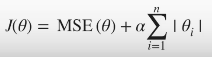

- 추가설명 : 라쏘 회귀는 릿지 회귀보다 조금 더 극단적인 규제를 한다.    
  그래서 급격하게 회귀계수를 감소시켜서 L1 규제를 통해 중요한 피처만 선택하고 나머지는 0으로 만들어 버린다.
- 아래의 이미지를 보면 A와 E의 값이 회귀계수가 큰 값인데 라쏘 회귀를 alpha 3으로 하므로써 완전히 사라지게 됨

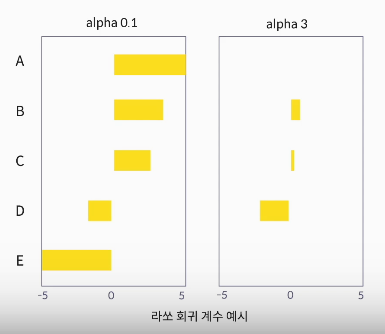

In [30]:
# 라쏘 회귀

from sklearn.linear_model import Lasso
model = Lasso()                    # 라쏘 회귀도 기본 alpha값이 1이다.
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)   

4179.152642946343

In [32]:
# 회귀 계수 데이터 프레임 만들어서 저장하기
coef = pd.DataFrame(data = model.coef_, index = X_train.columns, columns = ['alpha1']) # 변수에 저장해주기
coef

,alpha1
age,0.000000
sex,-0.000000
bmi,343.589790
bp,46.369923
s1,0.000000
s2,0.000000
s3,-0.000000
s4,0.000000
s5,245.170617
s6,0.000000


* 위처럼 중요한 피처의 계수들만 남기고 나머지 계수들은 모두 0이 된다.

In [39]:
# 라쏘 회귀 (alpha = 2)
model = Lasso(alpha = 2)                    
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)

6398.637179449031

In [40]:
# 회귀 계수 (alphar값 2로 조정한 결과)
coef['alpha2'] = model.coef_
coef

,alpha1,alpha2,alpha0.05
age,0.000000,0.000000,-0.000000
sex,-0.000000,0.000000,-198.948213
bmi,343.589790,42.963888,487.198584
bp,46.369923,0.000000,340.490360
s1,0.000000,0.000000,-95.576361
s2,0.000000,0.000000,-0.000000
s3,-0.000000,-0.000000,-189.867452
s4,0.000000,0.000000,10.487703
s5,245.170617,0.000000,457.332197
s6,0.000000,0.000000,39.292925


In [41]:
# 라쏘 회귀 (alpha = 0.05)
model = Lasso(alpha = 0.05)                    
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)

2703.4583679188177

In [42]:
# 회귀 계수 (alphar값 0.05로 조정한 결과)
coef['alpha0.05'] = model.coef_
coef

,alpha1,alpha2,alpha0.05
age,0.000000,0.000000,-0.000000
sex,-0.000000,0.000000,-198.948213
bmi,343.589790,42.963888,487.198584
bp,46.369923,0.000000,340.490360
s1,0.000000,0.000000,-95.576361
s2,0.000000,0.000000,-0.000000
s3,-0.000000,-0.000000,-189.867452
s4,0.000000,0.000000,10.487703
s5,245.170617,0.000000,457.332197
s6,0.000000,0.000000,39.292925


## 엘라스틱넷 회귀

* 회귀를 위한 선형 모델
* L2규제와 L1 규제 결합한 회귀
* 시간이 상대적으로 오래걸립니다.
     
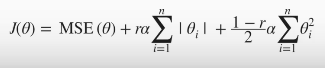

In [43]:
# 엘라스틱넷 회귀

from sklearn.linear_model import ElasticNet
model = ElasticNet()                    # 엘라스틱넷 회귀도 기본 alpha값이 1이다.
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred)   

6539.270961171604

In [44]:
# 엘라스틱넷 회귀

from sklearn.linear_model import ElasticNet

# 엘라스틱넷 회귀에서 alpha = 0.0001으로 조절한다.
# 엘라스틱넷 회귀는 l1 + l2 이기 때문에 l1_ratio를 조절할 수 있습니다. 여기서 l1_ratio = 0.6 으로 조정하기
model = ElasticNet(alpha = 0.0001, l1_ratio = 0.6)  
model.fit(X_train, y_train)        
pred = model.predict(X_test)       
mean_squared_error(y_test, pred) 

2675.6031657225317

# 랜덤포레스트 & XGBoost

 * 랜덤포레스트와 XGBoost는 분류뿐만 아니라 회귀에서도 자주 활용된다.
 * 실습을 통해 회귀에서 사용하는 법을 알아보겠습니다.

## 랜덤포레스트

* 여러 개의 의사결정 트리로 구성
* 앙상블 방법 중 배깅(bagging)방식
* 부트스트랩 샘플링 (데이터셋 중복 허용)
* 최종 다수결 투표

In [47]:
# 랜덤포레스트

from sklearn.ensemble import RandomForestRegressor # 분류에서는 Calssifier를 불러왔지만 회귀에서는 Regressor를 불러오면 된다.

model = RandomForestRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)
mean_squared_error(y_test, pred)

3262.712528089888

## XGBoost

* 트리 앙상블 중 성능이 좋은 알고리즘
* eXtreme Gradient Boosting을 줄여서 XGBoost 라고 한다.
* 약한 학습기가 계속해서 업데이트를 하며 좋은 모델을 만들어간다.

In [48]:
# XGBoost

from xgboost import XGBRegressor # 분류에서는 Calssifier를 불러왔지만 회귀에서는 Regressor를 불러오면 된다.

model = XGBRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)
mean_squared_error(y_test, pred)

4265.475533439266

* 위 예제에서는 랜덤포레스트와 XG부스트에 파라미터에 값을 조절하지 않아서 값이 높게 나왔지만 조절을 한다면 오차범위를 줄일 수 있다.

## 하이퍼파라미터 튜닝

* 아래 예제에서는 그리드 서치와 랜덤 서치를 활용해서 파라미터 값을 찾는 방법을 알려드리도록 하겠습니다.

In [54]:
# 라이브러리 불러오기
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

* **그리드서치**
    * 그리드 서치의 경우 모든 경우의 수를 탐색한다.
    * 아래 입력한 하이퍼파라미터의 값을 모두 비교해보고 최적의 하이퍼파라미터의 값을 알려준다.
    * 시간이 오래걸림

* **랜덤서치**
    * 랜덤서치의 경우 예를들어 5회 또는 10회 이런식으로 제한을 걸 수 있다.
    * 제한된 횟수 내에 랜덤하게 선택을해서 최적의 하이퍼파라미터의 값을 찾아준다.
    * 그리드 서치보다 상대적으로 오래걸리지 않음

In [50]:
# 하이퍼파라미터
params = {'learnin_rate' : [0.07, 0.05],
          'max_depth' : [3, 5, 7],
          'n_estimators' : [100, 200],
          'subsample' : [0.9, 0.8, 0.7]
         }

In [53]:
# 데이터셋 로드
def make_dataset2():
    dataset = load_diabetes()
    df = pd.DataFrame(dataset.data, columns = dataset.feature_names)
    df['target'] = dataset.target

    return df.drop('target', axis = 1), df['target']

X,y = make_dataset2()

### GridSearchCV

  * GridSearchCV를 통해 최적의 하이퍼파라미터를 찾음 (시간 오래 걸림)

In [60]:
# GridSearcgCV
xgb = XGBRegressor()
# data는 xgb를 사용할 예정
# paramiter는 params 위에서 변수에 넣은 값을 사용
# cv는 보통 5로 사용하지만 올래걸리기 때문에 3으로 조정
# n_jos는 코어를 전부다 사용
grid = GridSearchCV(xgb, params, cv = 3, n_jobs = -1)
grid.fit(X, y)

C:\Users\nini\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:44:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "learnin_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learnin_rate': [0.07, 0.05], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200],
                         'subsample': [0.9, 0.8, 0.7]})

In [62]:
# 최적의 하이퍼파라미터를 찾기
grid.best_params_

{'learnin_rate': 0.07, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}

In [66]:
# 하이퍼파라미터 튜닝

xgb = XGBRegressor(learning_rate = 0.07, 
                   max_depth = 3, 
                   n_estimators = 100, 
                   subsample = 0.7
                  )

xgb.fit(X_train, y_train)
xgb.predict(X_test)

mean_squared_error(y_test, pred)

4265.475533439266

### Random Search

  * Random Search는 GridSearchCV와 달리 랜덤으로 N개의 조합만 탐색한다 (시간 내 최적의 하이퍼파라미터 탐색)

In [67]:
# Random Search
xgb = XGBRegressor()
# RandomizedSearchCV는 n_iter 인자를 하나 더 추가한다.
# n_iter는 몇번을 돌릴건지 지정하는 숫자
grid = RandomizedSearchCV(xgb, params, cv = 3, n_iter = 10, n_jobs = -1)
grid.fit(X, y)

C:\Users\nini\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:07:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "learnin_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learnin_rate': [0.07, 0.05],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.9, 0.8, 0.7]})

In [68]:
grid.best_params_

{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learnin_rate': 0.07}

In [69]:
# 하이퍼파라미터 튜닝

xgb = XGBRegressor(learning_rate = 0.07, 
                   max_depth = 3, 
                   n_estimators = 100, 
                   subsample = 0.7
                  )

xgb.fit(X_train, y_train)
xgb.predict(X_test)

mean_squared_error(y_test, pred)

4265.475533439266

## 평가 (회귀)

평가지표 정리
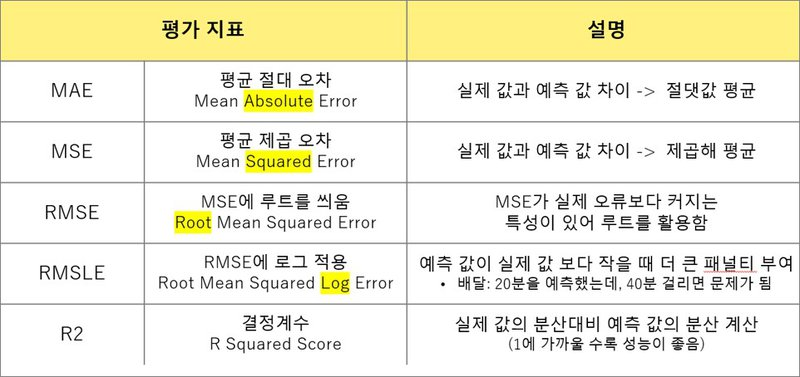

In [72]:
# MAE 평가지표 만들기

from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, pred)

51.83355545729734

In [73]:
# MSE 평가지표 만들기
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, pred)

4265.475533439266

In [74]:
# RMSE 평가지표 만들기
# RMSE의 경우 MSE에 루트를 한것이기 때문에 numpy를 이용하여 mean_squared_error에 루트 sqrt()를 사용한다.
import numpy as np

np.sqrt(mean_squared_error(y_test, pred))

65.31060812333067

In [76]:
# RMSLE 평가지표 만들기
# RMSLE는 RMSE에 로그가 더해진것
# sklearn에 MSLE가 있기 때문에 MSLE를 만들고 sqrt()를 사용해준다.
import numpy as np
from sklearn.metrics import mean_squared_log_error

np.sqrt(mean_squared_log_error(y_test, pred))

0.4780939100008851

In [77]:
# R2 스퀘어 지표 평가
from sklearn.metrics import r2_score

r2_score(y_test, pred)

0.3485356005294492